# Malicious URL Detector
This notebook was written to apply some machine learning concepts I have learned. Using a dataset containing a list of URLs sorted into two categories: benign or malicious. The model is trained on this data after some cleaning and preprocessing, before being evaluated using a train-test split and a Random Forest classifier.

## Data and Pre-processing

The dataset used is a two-column table containing more than 600,000 URLs. One column contains the raw URL string, and the other contains its label, either benign (safe) or a type of malicious activity (phishing, malware, etc.). Credits to sid321axn (Manu Siddhartha) on Kaggle for the dataset.

I ran standard data-cleaning operations, removing null values and duplicates. Since I am only working with text entries, computing averages for missing fields wasn't relevant here.

I also consolidated all malicious subtypes (phishing, malware, etc.) into a single "malicious" label. This simplifies the problem into binary classification to benign vs. malicious, which gives the model a better shot at generalizing rather than distinguishing between several malicious subcategories. 

In [5]:
import pandas as pd

# Read csv file and create a dataframe, run standard data cleaning operations
df = pd.read_csv('/kaggle/input/datasets/sid321axn/malicious-urls-dataset/malicious_phish.csv')

print("Number of null values: ")
print(df.isnull().sum())
print()
# No code for removing empty values since there were not any

dupes = df.duplicated().sum()
print("Duplicates removed: ")
print(dupes)
print()
df = df.drop_duplicates()

# rename values in second coloumn to benign or malicious only (since training on a subset of the dataset)
df['type'] = df['type'].apply(
    lambda x: 'benign' 
    if x == 'benign' 
    else 
    'malicious'
)

# print(df.head(10)) commented this line since the links are clickable on kaggle
print("Total number of entires: ")
print(len(df))

Number of null values: 
url     0
type    0
dtype: int64

Duplicates removed: 
10066

Total number of entires: 
641125


## Model Choice and Training

I used a Random Forest classifier as it's well suited for binary (and non-binary, but will probably work better for binary) classification tasks, handles noisy data well, and I had prior understanding of how it works.

Since URLs are raw strings and not numbers, I first converted them into numerical vectors using the 'BAAI/bge-small-en-v1.5' embedding model, which is a lightweight sentence transformer (from HuggingFace). This gave the model something it could actually learn from.

I then split the data 80/20 into training and test sets, fit the Random Forest on the training set, and evaluated predictions on the test set using the accuracy score.

Since the full dataset took too long for Kraggle to run (did not run after 40 minutes), I sampled 6,000 entries for training instead.

In [6]:
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# Model
model = SentenceTransformer('BAAI/bge-small-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
df = df.sample(n=6000, random_state=17).reset_index(drop=True) # smaller sample size
X = model.encode(df['url'].tolist())
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=17, test_size=0.2)

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Prepare random forest model
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

# Score model
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.3).astype(int)
y_test_binary = (y_test == 'malicious').astype(int)

rf.score(X_test, y_test)

0.8333333333333334

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test_binary, y_pred)) # Good f1-score nephew! Just this once!

              precision    recall  f1-score   support

           0       0.93      0.79      0.85       805
           1       0.67      0.88      0.76       395

    accuracy                           0.82      1200
   macro avg       0.80      0.83      0.81      1200
weighted avg       0.84      0.82      0.82      1200



## Evaluation & Conclusion

The model returned an accuracy of ~0.83, which is a pretty good result from my understanding, though one figure alone is not the best indicator of how well the model actually performed.

**My first results** (non-binary classes and 5,000 entries) had an accuracy somewhere in the mid 70's, a malicious recall of about 0.50(estimated average of all cases), and a benign recall of approximately 0.80. This tells me the model was mostly guessing benign and yielding many false negatives, likely due to the fact that most of the dataset has benign entries.

**My second run** with binary classes (either benign or malicious) and a larger sample (6,000 entries) had a precision of 0.83, a benign recall of 0.96, and a malicious recall of 0.56. Accuracy went up, but the model was still being a bit too safe with its guesses.

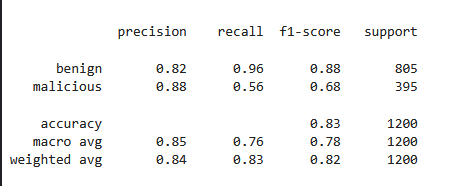

**My third and most recent run** yielded an accuracy of 83.33% with a much better recall. Benign dropped to 0.79, but malicious shot up to 0.88, which is great! In cases such as these, false negatives are generally worse than false positives; missing a malicious URL is more dangerous than flagging a safe one, so I was much happier with this result. Precision for benign shot up to 0.93 and for malicious went down to 0.67 (for real), but that's ML, there are tradeoffs.

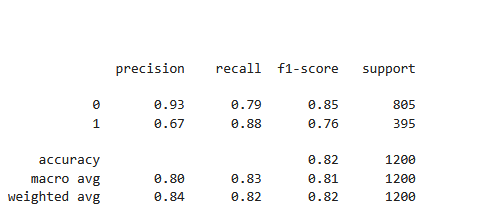

In conclusion, this was a success and a solid learning experience. I'm looking forward to building more Kaggle notebooks and eventually implementing this into a web application. 

## Saving the Model
I used joblib to save my trained model so that it can be used in a web application I will be developing with some collaborators. Outputs don't save accross sessions and duplicates overwrite.

In [25]:
import joblib
joblib.dump(rf, '/kaggle/working/url_model_1.pkl')
print("Model saved!")

Model saved!
